# Phase 1. 데이터 탐색·품질 점검 (EDA)

목적: `docs/project-plan.md` Phase 1 체크리스트를 확인하고, `CLAUDE.md`에 적힌 데이터 주의사항이
실제 수치로 어떻게 나타나는지 검증한다.

체크리스트:
- 행 수, 타깃 비율
- 컬럼별 결측률 (`MonthlyIncome`, `NumberOfDependents`)
- 연체 변수의 96/98 코드값 분포와 의미 추정
- `RevolvingUtilizationOfUnsecuredLines` 1 초과 값 분포
- 소득 결측·0일 때 `DebtRatio` 분포
- `age` 이상값(0 등)
- 중복 행
- 변수 간 상관(특히 연체 변수 3개)
- 변수별 타깃 비율 추이


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "AppleGothic"  # 그래프 한글 라벨 깨짐 방지 (macOS)
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../../data/raw"
TARGET = "SeriousDlqin2yrs"
DELINQ_COLS = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]


## 1. 데이터 로드

첫 번째 컬럼은 이름 없는 인덱스 컬럼이므로 `index_col=0`으로 읽는다.

In [2]:
train = pd.read_csv(f"{DATA_DIR}/cs-training.csv", index_col=0)
test = pd.read_csv(f"{DATA_DIR}/cs-test.csv", index_col=0)

print("train shape:", train.shape)
print("test shape:", test.shape)
train.head()


train shape: (150000, 11)
test shape: (101503, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
train.dtypes


SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## 2. 행 수, 타깃 비율

`cs-test.csv`에는 `SeriousDlqin2yrs` 컬럼 자체는 존재하지만 값이 모두 비어 있다(대회 채점용, 정답 비공개).
이후 분석은 `cs-training.csv` 기준으로 진행한다.


In [4]:
assert test[TARGET].isna().all(), "cs-test.csv의 타깃은 전부 결측이어야 한다"

n = len(train)
pos = train[TARGET].sum()
rate = pos / n
print(f"전체 행 수: {n:,}")
print(f"양성(연체) 건수: {pos:,}")
print(f"양성 비율: {rate:.4%}")

train[TARGET].value_counts(normalize=True).rename("비율").to_frame()


전체 행 수: 150,000
양성(연체) 건수: 10,026
양성 비율: 6.6840%


,비율
SeriousDlqin2yrs,
0,0.93316
1,0.06684


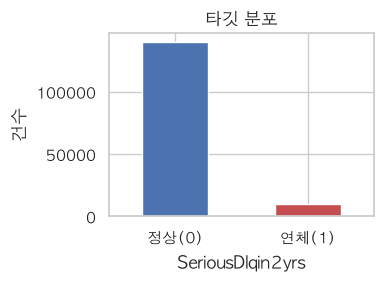

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
train[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["정상(0)", "연체(1)"], rotation=0)
ax.set_title("타깃 분포")
ax.set_ylabel("건수")
plt.tight_layout()
plt.show()


## 3. 컬럼별 결측률

In [6]:
missing = train.isna().sum().to_frame("결측 건수")
missing["결측률"] = missing["결측 건수"] / n
missing.sort_values("결측률", ascending=False)


,결측 건수,결측률
MonthlyIncome,29731,0.198207
NumberOfDependents,3924,0.026160
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000


`MonthlyIncome`, `NumberOfDependents`에 결측이 있는지, 비율이 CLAUDE.md에 적힌 대로 (소득 약 20%) 맞는지 확인한다.


In [7]:
for col in ["MonthlyIncome", "NumberOfDependents"]:
    r = train[col].isna().mean()
    print(f"{col}: 결측률 {r:.2%}")


MonthlyIncome: 결측률 19.82%
NumberOfDependents: 결측률 2.62%


## 4. 중복 행

In [8]:
dup_all = train.duplicated().sum()
dup_no_target = train.drop(columns=[TARGET]).duplicated().sum()
print(f"전체 컬럼 기준 완전 중복 행: {dup_all:,}")
print(f"타깃 제외 피처 기준 중복 행: {dup_no_target:,}")


전체 컬럼 기준 완전 중복 행: 609
타깃 제외 피처 기준 중복 행: 646


## 5. `age` 이상값

0세 등 비정상적인 나이가 있는지 확인한다. `age`는 민감 변수이므로 이상값 처리 방침과는 별개로
모델 사용·사유 코드 노출 정책은 Phase 4에서 별도로 정한다(`docs/project-plan.md` 미결정 사항 3).


In [9]:
print(train["age"].describe())
print()
print("age <= 0 인 행 수:", (train["age"] <= 0).sum())
train.loc[train["age"] <= 0]


count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

age <= 0 인 행 수: 1


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


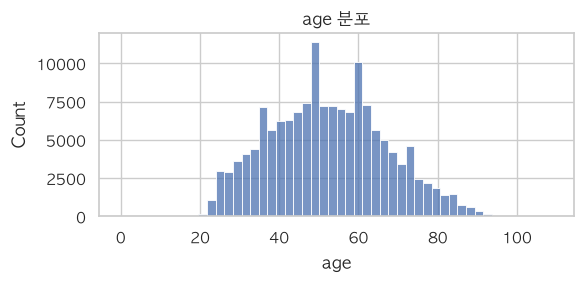

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(train["age"], bins=50, ax=ax)
ax.set_title("age 분포")
plt.tight_layout()
plt.show()


## 6. 연체 변수 3개 — 96/98 코드값

`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`에
96, 98처럼 정상 범위를 벗어난 코드값이 있는지, 몇 건인지, 세 변수에서 동시에 나타나는지 확인한다.


In [11]:
for col in DELINQ_COLS:
    print(f"--- {col} ---")
    print(train[col].value_counts().sort_index())
    print()


--- NumberOfTime30-59DaysPastDueNotWorse ---
NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

--- NumberOfTime60-89DaysPastDueNotWorse ---
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

--- NumberOfTimes90DaysLate ---
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64



In [12]:
code_rows = train[(train[DELINQ_COLS] >= 90).any(axis=1)]
print("연체 변수 중 하나라도 90 이상인 행 수:", len(code_rows))
code_rows[DELINQ_COLS + [TARGET]].describe(include="all")


연체 변수 중 하나라도 90 이상인 행 수: 269


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,SeriousDlqin2yrs
count,269.000000,269.000000,269.000000,269.000000
mean,97.962825,97.962825,97.962825,0.546468
std,0.270628,0.270628,0.270628,0.498764
min,96.000000,96.000000,96.000000,0.000000
25%,98.000000,98.000000,98.000000,0.000000
50%,98.000000,98.000000,98.000000,1.000000
75%,98.000000,98.000000,98.000000,1.000000
max,98.000000,98.000000,98.000000,1.000000


In [13]:
# 코드값(96/98)을 가진 행이 세 변수에서 항상 같이 나타나는지 확인
code_rows[DELINQ_COLS].drop_duplicates()


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1734,98,98,98
41945,96,96,96


In [14]:
print("코드값 행의 타깃 양성 비율:", code_rows[TARGET].mean())
print("전체 타깃 양성 비율:", train[TARGET].mean())


코드값 행의 타깃 양성 비율: 0.5464684014869888
전체 타깃 양성 비율: 0.06684


## 7. `RevolvingUtilizationOfUnsecuredLines` 1 초과 값

정의상 사용률이므로 1(100%)을 넘는 값은 이상값 후보다. 분포와 건수를 확인한다.


In [15]:
col = "RevolvingUtilizationOfUnsecuredLines"
print(train[col].describe())
print()
over1 = train[train[col] > 1]
print(f"1 초과 행 수: {len(over1):,} ({len(over1) / n:.2%})")
over1[col].describe()


count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

1 초과 행 수: 3,321 (2.21%)


count     3321.000000
mean       259.773362
std       1659.034074
min          1.000059
25%          1.019996
50%          1.074633
75%          1.301096
max      50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

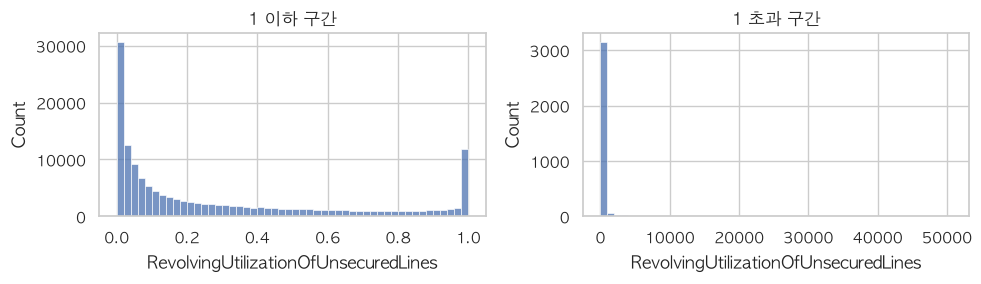

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(train[train[col] <= 1][col], bins=50, ax=axes[0])
axes[0].set_title("1 이하 구간")
sns.histplot(over1[col], bins=50, ax=axes[1])
axes[1].set_title("1 초과 구간")
plt.tight_layout()
plt.show()


## 8. 소득 결측·0일 때 `DebtRatio`

`MonthlyIncome`이 결측이거나 0일 때 `DebtRatio`가 비정상적으로 크게 나타나는지 확인한다.
(부채 비율 정의상 소득이 0에 가까우면 값이 발산하거나, 실제로는 부채 금액 자체가 들어간 것으로 보이는 현상)


In [17]:
income_missing = train["MonthlyIncome"].isna()
income_zero = train["MonthlyIncome"] == 0

print("소득 결측 시 DebtRatio 요약")
print(train.loc[income_missing, "DebtRatio"].describe())
print()
print("소득 0일 때 DebtRatio 요약")
print(train.loc[income_zero, "DebtRatio"].describe())
print()
print("소득 결측도 0도 아닐 때 DebtRatio 요약")
normal_income = ~income_missing & ~income_zero
print(train.loc[normal_income, "DebtRatio"].describe())


소득 결측 시 DebtRatio 요약
count     29731.000000
mean       1673.396556
std        4248.372895
min           0.000000
25%         123.000000
50%        1159.000000
75%        2382.000000
max      329664.000000
Name: DebtRatio, dtype: float64

소득 0일 때 DebtRatio 요약
count     1634.000000
mean      1573.567319
std       2818.015889
min          0.000000
25%         96.000000
50%        930.000000
75%       2185.250000
max      60212.000000
Name: DebtRatio, dtype: float64

소득 결측도 0도 아닐 때 DebtRatio 요약


count    118635.000000
mean          5.291856
std         199.774225
min           0.000000
25%           0.141496
50%           0.292454
75%           0.473289
max       61106.500000
Name: DebtRatio, dtype: float64


/var/folders/yk/y8jtmy9n3mqfnj05f__7_wqr0000gn/T/ipykernel_66145/382094871.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["소득 결측", "소득 0", "정상 소득"])
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


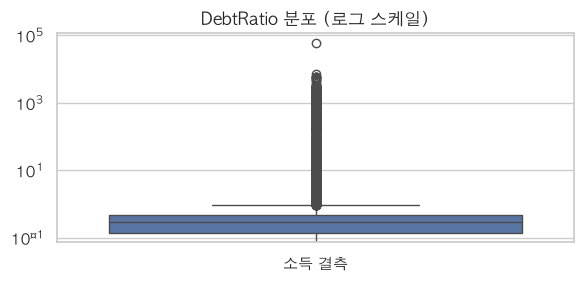

In [18]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.boxplot(
    data=[
        train.loc[income_missing, "DebtRatio"].dropna(),
        train.loc[income_zero, "DebtRatio"].dropna(),
        train.loc[normal_income, "DebtRatio"].dropna(),
    ],
    ax=ax,
)
ax.set_xticklabels(["소득 결측", "소득 0", "정상 소득"])
ax.set_yscale("log")
ax.set_title("DebtRatio 분포 (로그 스케일)")
plt.tight_layout()
plt.show()


## 9. 변수 간 상관 (특히 연체 변수 3개)

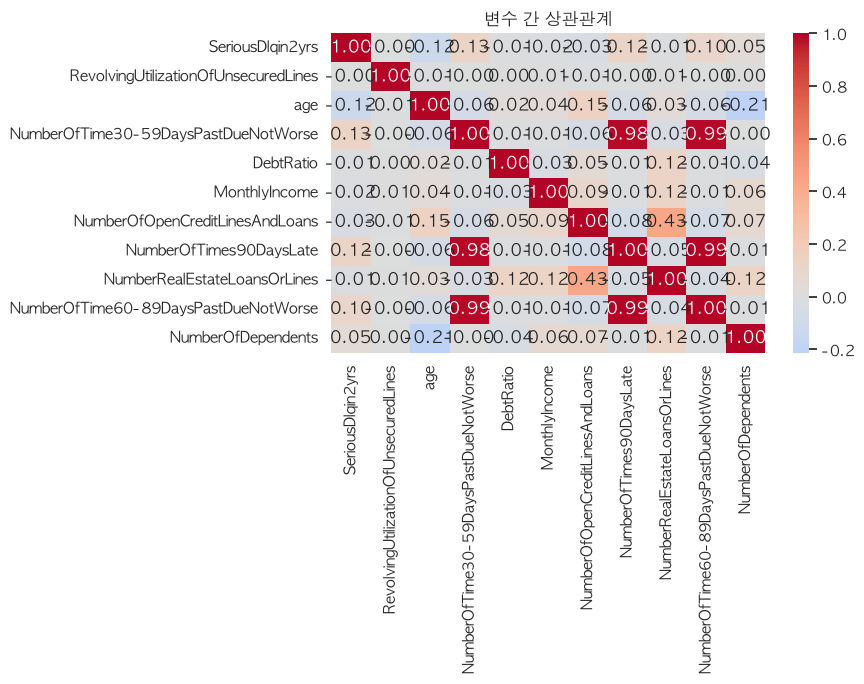

In [19]:
corr = train.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("변수 간 상관관계")
plt.tight_layout()
plt.show()


In [20]:
print("연체 변수 3개 간 상관")
train[DELINQ_COLS].corr()


연체 변수 3개 간 상관


,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.000000,0.987005,0.983603
NumberOfTime60-89DaysPastDueNotWorse,0.987005,1.000000,0.992796
NumberOfTimes90DaysLate,0.983603,0.992796,1.000000


## 10. 변수별 타깃 비율 추이

주요 변수를 구간화해 구간별 연체율(타깃 평균)이 어떻게 변하는지 확인한다.

In [21]:
def target_rate_by_bin(df, col, bins=10, target=TARGET):
    binned = pd.qcut(df[col], q=bins, duplicates="drop")
    return df.groupby(binned, observed=True)[target].agg(["mean", "count"]).rename(
        columns={"mean": "연체율", "count": "건수"}
    )

for col in ["age", "DebtRatio", "NumberOfOpenCreditLinesAndLoans"]:
    print(f"--- {col} 구간별 연체율 ---")
    display(target_rate_by_bin(train, col))
    print()


--- age 구간별 연체율 ---


,연체율,건수
age,,
"(-0.001, 33.0]",0.113550,17085
"(33.0, 39.0]",0.095851,14919
"(39.0, 44.0]",0.086398,15799
"(44.0, 48.0]",0.081406,14741
"(48.0, 52.0]",0.077027,14826
"(52.0, 56.0]",0.065780,14214
"(56.0, 61.0]",0.049710,16878
"(61.0, 65.0]",0.037484,12939
"(65.0, 72.0]",0.026652,14258



--- DebtRatio 구간별 연체율 ---


,연체율,건수
DebtRatio,,
"(-0.001, 0.0309]",0.053800,15000
"(0.0309, 0.134]",0.068200,15000
"(0.134, 0.214]",0.060333,15000
"(0.214, 0.287]",0.054067,15000
"(0.287, 0.367]",0.056133,15000
"(0.367, 0.468]",0.067400,15000
"(0.468, 0.649]",0.084128,15001
"(0.649, 4.0]",0.113317,15108
"(4.0, 1267.0]",0.060822,14896



--- NumberOfOpenCreditLinesAndLoans 구간별 연체율 ---


,연체율,건수
NumberOfOpenCreditLinesAndLoans,,
"(-0.001, 3.0]",0.107029,22050
"(3.0, 4.0]",0.064002,11609
"(4.0, 5.0]",0.063336,12931
"(5.0, 6.0]",0.055384,13614
"(6.0, 8.0]",0.052428,25807
"(8.0, 9.0]",0.058476,11355
"(9.0, 10.0]",0.059643,9624
"(10.0, 12.0]",0.059572,15326
"(12.0, 15.0]",0.064295,13858


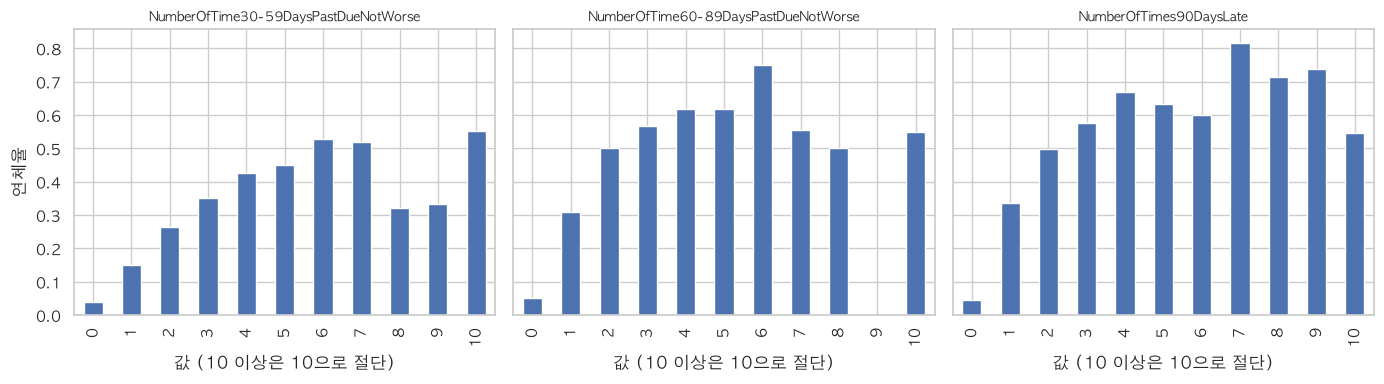

In [22]:
fig, axes = plt.subplots(1, len(DELINQ_COLS), figsize=(14, 4), sharey=True)
for ax, col in zip(axes, DELINQ_COLS):
    capped = train[col].clip(upper=10)
    rate = train.groupby(capped)[TARGET].mean()
    rate.plot(kind="bar", ax=ax, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("값 (10 이상은 10으로 절단)")
axes[0].set_ylabel("연체율")
plt.tight_layout()
plt.show()


## 11. 데이터 사전 대조

`Data Dictionary.xls`와 실제 컬럼이 일치하는지 확인한다.


In [23]:
data_dict = pd.read_excel(f"{DATA_DIR}/Data Dictionary.xls", engine="xlrd")
data_dict.columns = ["변수명", "설명", "타입"]
data_dict = data_dict.iloc[1:].reset_index(drop=True)
data_dict


,변수명,설명,타입
0,SeriousDlqin2yrs,Person experienced 90 days past due delinquenc...,Y/N
1,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lin...,percentage
2,age,Age of borrower in years,integer
3,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days p...,integer
4,DebtRatio,"Monthly debt payments, alimony,living costs di...",percentage
5,MonthlyIncome,Monthly income,real
6,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loa...,integer
7,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or m...,integer
8,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans inclu...,integer
9,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days p...,integer


In [24]:
dict_vars = set(data_dict["변수명"])
actual_vars = set(train.columns)
print("사전에는 있는데 데이터에 없는 컬럼:", dict_vars - actual_vars)
print("데이터에는 있는데 사전에 없는 컬럼:", actual_vars - dict_vars)


사전에는 있는데 데이터에 없는 컬럼: set()
데이터에는 있는데 사전에 없는 컬럼: set()


## 12. 요약

체크리스트 결과를 바탕으로 수치를 정리한다. (실행 후 위 결과를 참고해 서술을 채운다)

- 행 수 / 타깃 비율:
- 결측 컬럼과 비율:
- 96/98 코드값 건수와 처리 방향:
- `RevolvingUtilizationOfUnsecuredLines` 1 초과 건수:
- 소득 결측·0일 때 `DebtRatio` 특이사항:
- `age` 이상값:
- 중복 행:
- 상관관계 특이사항:
- 다음 단계(Phase 2 전처리 방침 초안):
